# 02 — Data Pipeline & Dataloader Visualization

This notebook explores what happens to the road-damage images and
their bounding-box annotations before they are provided to the YOLO
model.

 I will inspect:

- Raw images and YOLO annotations
- Image preprocessing
- Bounding-box transformations
- Training augmentations
- The Ultralytics dataset
- The Ultralytics dataloader
- The final batch received by the model

## Imports 

In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 3.1 MB/s eta 0:00:00


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
import yaml

from ultralytics import YOLO
import ultralytics

print("Ultralytics:", ultralytics.__version__)

Ultralytics: 8.4.131


## Dataset Paths

In [11]:
DATASET_ROOT = Path("/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT")
splits=["train","val","test"]
YAML_PATH = "/kaggle/input/datasets/gracyyadav79/data-config/data.yaml"
with open(YAML_PATH) as f:
    data = yaml.safe_load(f)
data 

{'path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT',
 'train': 'train/images',
 'val': 'val/images',
 'test': 'test/images',
 'names': {0: 'Longitudinal crack',
  1: 'Transverse crack',
  2: 'Alligator crack',
  3: 'Other corruption',
  4: 'Pothole'}}

## Class Names

The dataset contains five road-damage classes.

The verified mapping is:

- 0 → Longitudinal crack
- 1 → Transverse crack
- 2 → Alligator crack
- 3 → Other corruption
- 4 → Pothole

##  Verify Dataset paths

In [12]:
for split in splits:
    path = DATASET_ROOT / data[split]
    print(split, ":", path.exists(), "|", len(list(path.glob("*"))), "images")

train : True | 26869 images
val : True | 5758 images
test : True | 5758 images


## YOLO Data Pipeline

During training, the raw dataset passes through several stages:

    Image + Labels
          ↓
    YOLODataset
          ↓
    Loading
          ↓
    Preprocessing
          ↓
    Augmentation
          ↓
    Bounding-box transformation
          ↓
    Tensor conversion
          ↓
    DataLoader
          ↓
         Batch
          ↓
      YOLO Model

Ultralytics handles these operations internally.

## Image and Bounding Boxes Must Stay Synchronized

In object detection, transforming an image also requires transforming
its bounding boxes.

For example, after a horizontal flip:

    x_center' = 1 - x_center

while the bounding-box width, height and y-coordinate remain
unchanged.

Therefore, detection augmentation cannot simply modify the image
alone. The corresponding annotations must also be updated.

## Load YOLO

We load a pretrained YOLOv8 model.

The model is not trained in this notebook.

We use the ultralytics package so that we can inspect the dataset and dataloader components used by the training pipeline.

In [13]:
model = YOLO("yolov8n.pt")

## Ultralytics Dataset and Dataloader

Ultralytics does not directly send image files to the model.

It creates a dataset object that loads and processes individual
samples, and a dataloader that combines these samples into batches.

In [14]:
from ultralytics.data.dataset import YOLODataset
from ultralytics.data.build import build_dataloader
from ultralytics.data.base import BaseDataset

print(YOLODataset)
print(build_dataloader)
print(BaseDataset)

<class 'ultralytics.data.dataset.YOLODataset'>
<function build_dataloader at 0x7cad51e8c900>
<class 'ultralytics.data.base.BaseDataset'>


In [15]:
import inspect
print(inspect.signature(BaseDataset.__init__))

(self, img_path: 'str | list[str]', imgsz: 'int' = 640, cache: 'bool | str' = False, augment: 'bool' = True, hyp: 'dict[str, Any]' = IterableSimpleNamespace(task='detect', mode='train', model=None, data=None, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=True, cls_remap=True, optimizer='auto', verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=0.0, compile=False, channels_last=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split='val', save_json=False, conf=None, iou=0.7, max_det=300, quantize=None, dnn=False, plots=True, end2end=None, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_tx

In [16]:
print(inspect.signature(YOLODataset.__init__))

(self, *args, data: 'dict | None' = None, task: 'str' = 'detect', **kwargs)


# Dataset

### Creating The Training Dataset

`YOLODataset` uses `BaseDataset` internally.

The parent dataset requires training hyperparameters (`hyp`) in
addition to the image path and image size.

I will therefore provide the configuration explicitly and create the
dataset for inspection.


In [17]:
from ultralytics.cfg import get_cfg

hyp = get_cfg()
print(hyp.imgsz, hyp.fliplr, hyp.mosaic)

640 0.5 1.0


## Dataset with no augmentation

In [19]:
## Creating the Ultralytics YOLODataset
no_aug_dataset = YOLODataset(
    str(DATASET_ROOT / "train" / "images"),
    data = data,
    task='detect',
    imgsz=640,
    augment=False,
    hyp=hyp
)

WARNING ⚠️ Slow image access detected (ping: 1.2±0.1 ms, read: 7.3±0.5 MB/s, size: 79.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
Scanning /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels... 26869 images, 8097 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 26869/26869 121.0it/s 3:420.1ss
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images/Japan_006916.jpg: 1 duplicate labels removed
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images/Japan_011427.jpg: 1 duplicate labels removed
WARNING ⚠️ Cache directory /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train is not writable, cache not saved.


In [21]:
print("Number of samples :", len(no_aug_dataset))

Number of samples : 26869


## Inspecting One Processed Sample

The `YOLODataset` has now scanned and prepared the training dataset.

We retrieve one sample to see exactly what information Ultralytics
produces for a single image.

In [23]:
sample_no_aug = no_aug_dataset[0]

print(sample_no_aug.keys())

dict_keys(['im_file', 'ori_shape', 'resized_shape', 'ratio_pad', 'img', 'cls', 'bboxes', 'batch_idx'])


In [24]:
print("Image file:", sample_no_aug["im_file"])
print("Original shape:", sample_no_aug["ori_shape"])
print("Resized shape:", sample_no_aug["resized_shape"])
print("Ratio & padding:", sample_no_aug["ratio_pad"])

Image file: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images/China_Drone_000001.jpg
Original shape: (512, 512)
Resized shape: (640, 640)
Ratio & padding: ((1.25, 1.25), (0, 0))


In [25]:
print("Image tensor:", sample_no_aug["img"].shape)
print("Classes:", sample_no_aug["cls"].shape)
print("Boxes:", sample_no_aug["bboxes"].shape)
print("Batch index:", sample_no_aug["batch_idx"].shape)

Image tensor: torch.Size([3, 640, 640])
Classes: torch.Size([2, 1])
Boxes: torch.Size([2, 4])
Batch index: torch.Size([2])


## Raw(Original) Image Loading

In [26]:
original = Image.open(sample_no_aug["im_file"]).convert("RGB")
print("Original size :", original.size)

Original size : (512, 512)


## Orignal vs Processed Image

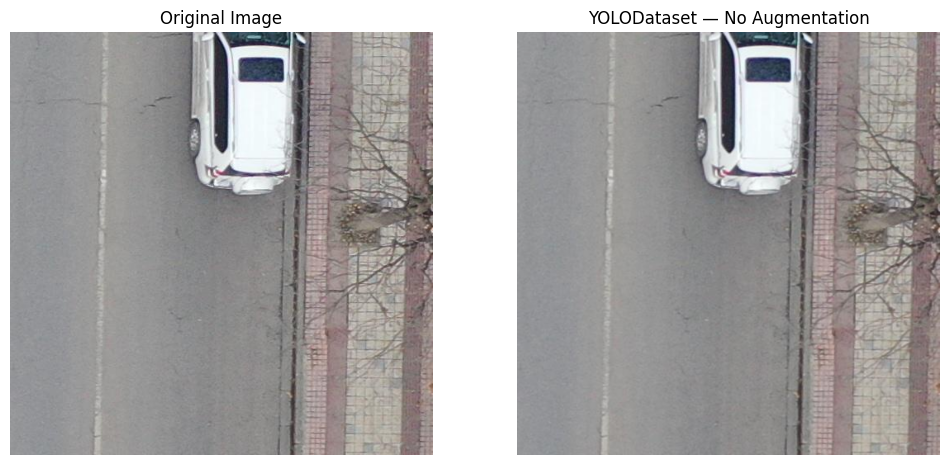

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(original)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(sample_no_aug["img"].permute(1, 2, 0).numpy())
ax[1].set_title("YOLODataset — No Augmentation")
ax[1].axis("off")

plt.show()

## Inspecting Classes and Bounding Boxes

The processed sample contains four objects.

`cls` stores the class ID for each object, while `bboxes` stores
the corresponding bounding-box coordinates.

The bounding boxes here are the coordinates produced by the
Ultralytics dataset pipeline, not the raw text representation
directly read from the `.txt` annotation file.

In [28]:
print("Classes:\n", sample_no_aug["cls"])
print("\nBounding boxes:\n", sample_no_aug["bboxes"])
print(type(sample_no_aug["bboxes"]))

Classes:
 tensor([[1.],
        [0.]])

Bounding boxes:
 tensor([[0.2070, 0.1650, 0.3594, 0.0566],
        [0.2100, 0.3770, 0.0488, 0.3086]])
<class 'torch.Tensor'>


In [29]:
import inspect

print(inspect.getsource(YOLODataset.result_to_label))

    def result_to_label(self, result: list) -> tuple[dict | None, int, int, int, int, str]:
        """Convert one verification result into a label dict and scan counter increments.

        Args:
            result (list): One result from the verification function returned by `verify_args`.

        Returns:
            (tuple): (label dict or None, missing, found, empty, corrupt, message).
        """
        im_file, lb, shape, segments, keypoint, nm_f, nf_f, ne_f, nc_f, msg = result
        label = (
            {
                "im_file": im_file,
                "shape": shape,
                "cls": lb[:, 0:1],  # n, 1
                "bboxes": lb[:, 1:],  # n, 4
                "segments": segments,
                "keypoints": keypoint,
                "normalized": True,
                "bbox_format": "xywh",
            }
            if im_file
            else None
        )
        return label, nm_f, nf_f, ne_f, nc_f, msg



In [31]:
print("Normalized:", True)
print("Format:", "xywh")
print("Boxes:\n", sample_no_aug["bboxes"])

Normalized: True
Format: xywh
Boxes:
 tensor([[0.2070, 0.1650, 0.3594, 0.0566],
        [0.2100, 0.3770, 0.0488, 0.3086]])


### Bunding Box Format

In [32]:
print("Min : ", sample_no_aug["bboxes"].min().item())
print("Max : ", sample_no_aug["bboxes"].max().item())

Min :  0.04882800579071045
Max :  0.37695300579071045


## Visualizing the Processed Bounding Boxes

The dataset stores bounding boxes as normalized `(x_center, y_center,
width, height)`.

For visualization, we convert them to pixel coordinates and draw
the boxes on the processed 640×640 image.

This allows us to verify that the image and annotations remain
correctly aligned after preprocessing.

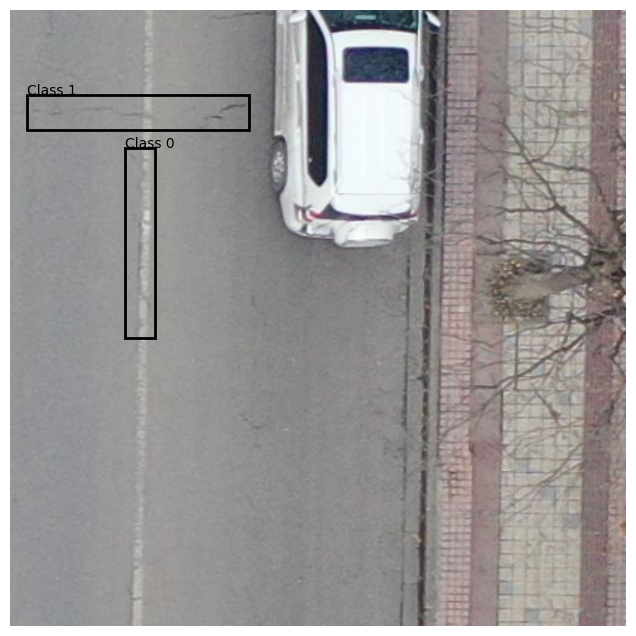

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img = sample_no_aug["img"].permute(1, 2, 0).numpy()
h, w = img.shape[:2]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)

for cls, box in zip(sample_no_aug["cls"], sample_no_aug["bboxes"]):
    xc, yc, bw, bh = box

    x1 = (xc - bw / 2) * w
    y1 = (yc - bh / 2) * h
    box_w = bw * w
    box_h = bh * h

    rect = patches.Rectangle(
        (x1, y1), box_w, box_h,
        fill=False, linewidth=2
    )
    ax.add_patch(rect)
    ax.text(x1, y1, f"Class {int(cls)}")

ax.axis("off")
plt.show()

In [39]:
print("Number of objects:", len(sample_no_aug["cls"]))
print("Number of boxes:", len(sample_no_aug["bboxes"]))

Number of objects: 2
Number of boxes: 2


## Visualizing the multiples bboxes 

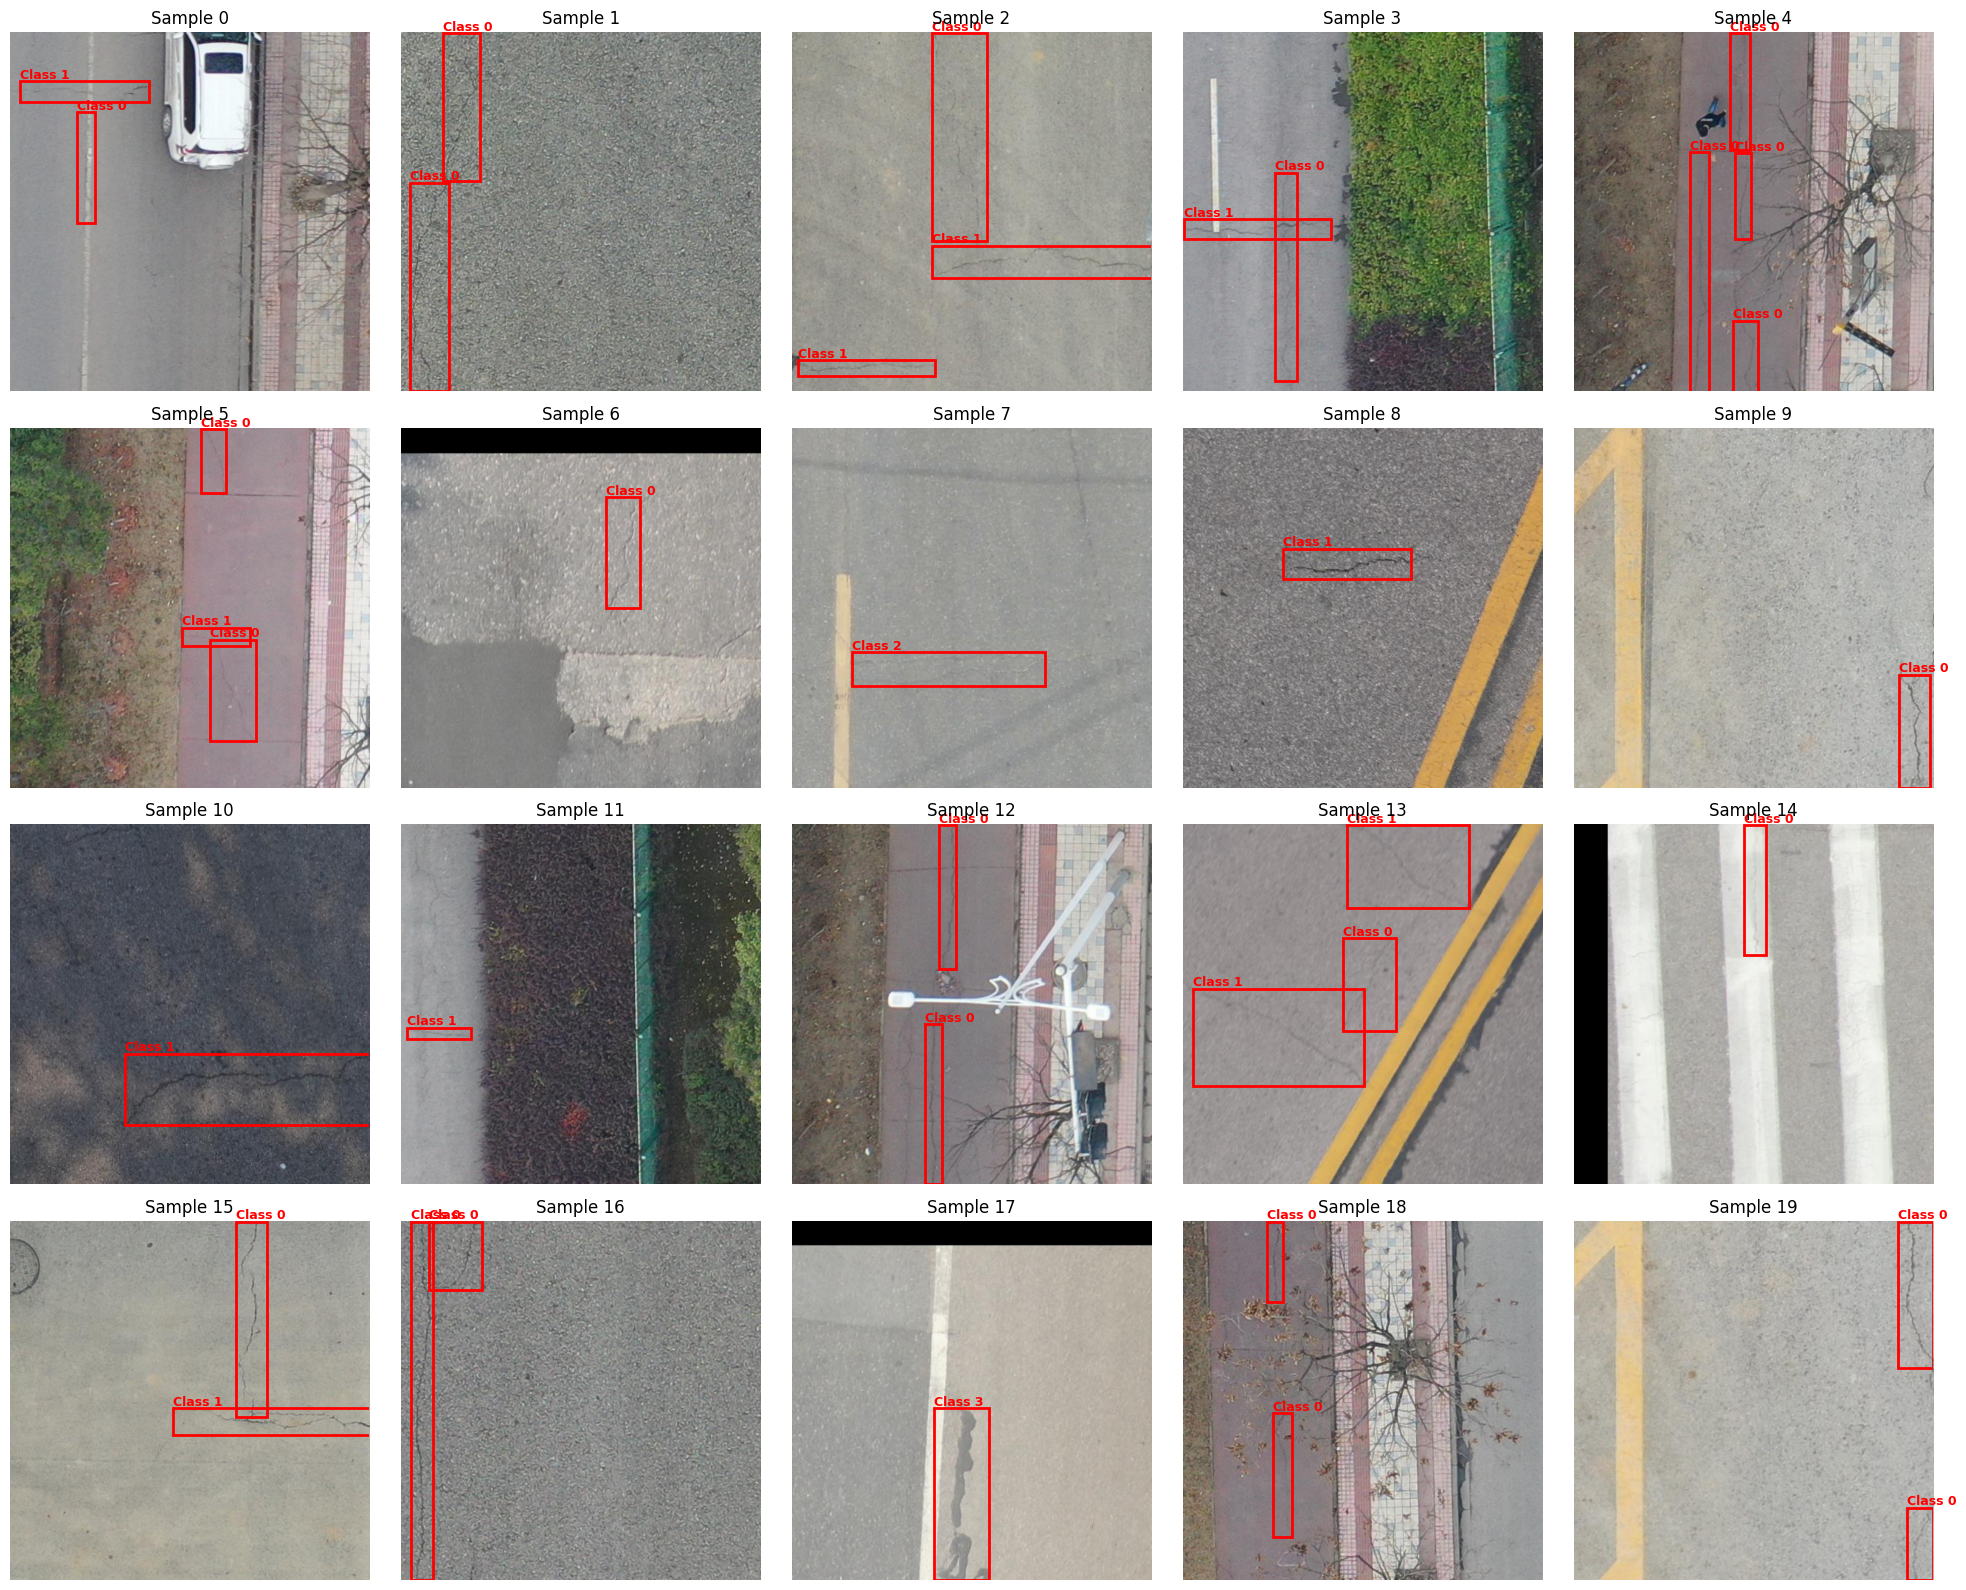

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten() 

indices = range(20) 

for i, idx in enumerate(indices):
    sample = no_aug_dataset[idx]
    
    img = sample["img"].permute(1, 2, 0).numpy()
    h, w = img.shape[:2]

    ax = axes[i]
    ax.imshow(img)

    for cls, box in zip(sample["cls"], sample["bboxes"]):
        xc, yc, bw, bh = box.tolist()

        x1 = (xc - bw / 2) * w
        y1 = (yc - bh / 2) * h

        rect = patches.Rectangle(
            (x1, y1), bw * w, bh * h,
            fill=False, linewidth=2, edgecolor='red' # Added explicit color for visibility
        )
        ax.add_patch(rect)
        
        # Shifted text slightly up (y1 - 5) and added color so it doesn't blend into the box
        ax.text(x1, y1 - 5, f"Class {int(cls)}", color='red', fontsize=9, weight='bold')

    ax.set_title(f"Sample {idx}")
    ax.axis("off")

# 4. Automatically adjust spacing so titles and images don't overlap
plt.tight_layout()
plt.show()

## Visualizing the Training Augmentation 

In [45]:
dataset_aug = YOLODataset(
    str(DATASET_ROOT / "train" / "images"),
    data=data,
    task="detect",
    imgsz=640,
    augment=True,
    hyp=hyp
)

Fast image access ✅ (ping: 0.0±0.0 ms, read: 67.2±50.7 MB/s, size: 290.2 KB)
Scanning /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/labels... 26869 images, 8097 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 26869/26869 528.9it/s 50.8s0.0ss
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images/Japan_006916.jpg: 1 duplicate labels removed
/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train/images/Japan_011427.jpg: 1 duplicate labels removed
WARNING ⚠️ Cache directory /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/train is not writable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


##  Augmented Sample

 retrieve the same dataset index with augmentation enabled.

Because some augmentations are random, the resulting image may look
very different from the original image.

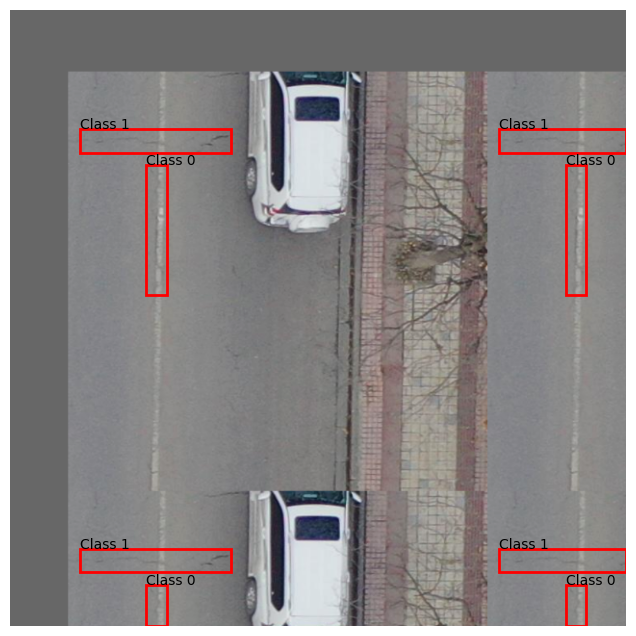

In [46]:
sample_aug = dataset_aug[0]

img = sample_aug["img"].permute(1, 2, 0).numpy()
h, w = img.shape[:2]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)

for cls, box in zip(sample_aug["cls"], sample_aug["bboxes"]):
    xc, yc, bw, bh = box.tolist()

    x1 = (xc - bw / 2) * w
    y1 = (yc - bh / 2) * h

    rect = patches.Rectangle(
        (x1, y1), bw * w, bh * h,
        fill=False, linewidth=2,color="red"
    )

    ax.add_patch(rect)
    ax.text(x1, y1, f"Class {int(cls)}")

ax.axis("off")
plt.show()

# Dataloader

## Creating the DATALOADER

A dataset provides one sample at a time.
During Training,YOLO processes multiple images togethere as a batch.
The DataLoader is responsible for retreiving samples from the dataset and organizing them into batches.


In [47]:
from ultralytics.data.build import build_dataloader

loader = build_dataloader(
    no_aug_dataset,
    batch=4,
    workers=2,
    shuffle=True
)
print("Number of Batches : ", len(loader))

Number of Batches :  6718


## Inspecting a Batch

In [49]:
batch = next(iter(loader))
print(batch.keys())

dict_keys(['batch_idx', 'bboxes', 'cls', 'im_file', 'img', 'ori_shape', 'ratio_pad', 'resized_shape'])


In [50]:
print("Images:", batch["img"].shape)
print("Classes:", batch["cls"].shape)
print("Boxes:", batch["bboxes"].shape)
print("Batch indices:", batch["batch_idx"].shape)

Images: torch.Size([4, 3, 640, 640])
Classes: torch.Size([12, 1])
Boxes: torch.Size([12, 4])
Batch indices: torch.Size([12])


In [51]:
print("Batch indices:", batch["batch_idx"].tolist())

Batch indices: [0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 3.0]


In [52]:
for i in range(4):
    count = (batch["batch_idx"] == i).sum().item()
    print(f"Image {i}: {count} objects")

Image 0: 3 objects
Image 1: 5 objects
Image 2: 3 objects
Image 3: 1 objects


##  Visualizing a Data loader Detection Batch

We visualize all images in the batch and draw their corresponding
bounding boxes.

The `batch_idx` values are used to select only the boxes belonging
to each image.

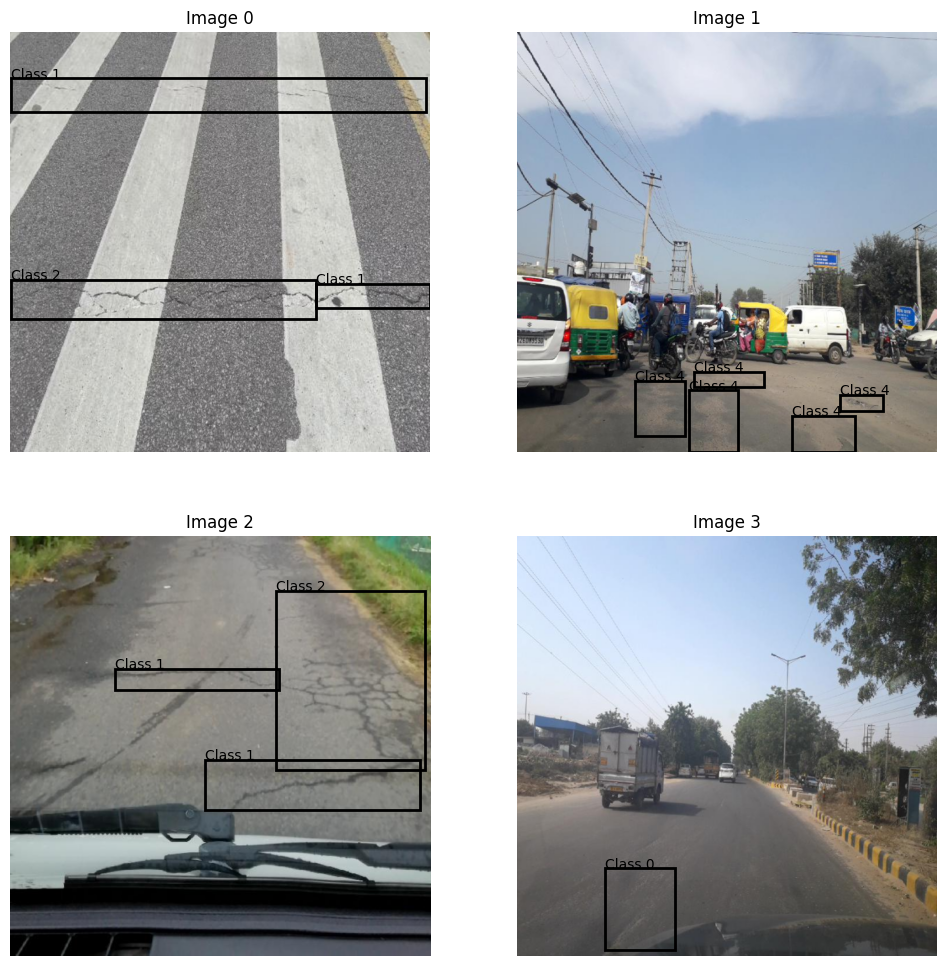

In [53]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax = ax.ravel()

for i in range(4):
    img = batch["img"][i].permute(1, 2, 0).numpy()
    ax[i].imshow(img)

    mask = batch["batch_idx"] == i

    for cls, box in zip(batch["cls"][mask], batch["bboxes"][mask]):
        xc, yc, bw, bh = box.tolist()

        x1 = (xc - bw / 2) * 640
        y1 = (yc - bh / 2) * 640

        rect = patches.Rectangle(
            (x1, y1), bw * 640, bh * 640,
            fill=False, linewidth=2
        )

        ax[i].add_patch(rect)
        ax[i].text(x1, y1, f"Class {int(cls)}")

    ax[i].set_title(f"Image {i}")
    ax[i].axis("off")

plt.show()

In [54]:
print("Image dtype:", batch["img"].dtype)
print("Image range:", batch["img"].min().item(), "to", batch["img"].max().item())
print("Class dtype:", batch["cls"].dtype)
print("Box dtype:", batch["bboxes"].dtype)

Image dtype: torch.uint8
Image range: 0 to 255
Class dtype: torch.float32
Box dtype: torch.float32
